In [1]:
#Se debe cargar a local los siguientes xlsx:
#01_BASE_CAUDALES_SECTORES_LIMA
#02_ROTURAS_RED_PRIMARIA_SECUNDARIA_LIMA
#06_REDES_CONEXIONES_LIMA


# ============================================================
# Instalación de librerías
# ============================================================
# !pip install -q pandas numpy openpyxl scikit-learn matplotlib seaborn

import os, re, sys, copy, shutil, warnings
#os= Permite lectura de archivos y foldes mediante el path (en este caso colab)
#re = Expreciones regulares para operación complejas de la cadena
#sys = Asceso al sistema para parámetros específicos
#copy = Permite la copia de mensajes superficiales y profundo de los objetos
#shutil =  Permite operaciones de alto nivel como movimiento de archivos complejos
#warnings = Permite controlar y emitir mesajes de emergencia por el usuario
import datetime as dt # Importación de la libreria datetime(formatos de fechas)
from pathlib import Path #Librería de ruta de los archivos

import numpy as np # Linear algebra
import pandas as pd # Procesamiento de datos

import matplotlib.pyplot as plt #Visualización de datos
import seaborn as sns #Visualización de datos estadísticos

from sklearn.cluster import KMeans #Kmeans en el modelo
from sklearn.preprocessing import StandardScaler # Escala del modelo del cluster
from sklearn.metrics import silhouette_score # Puntaje del modelo cluster

# Permite carga de datos xlsx
from openpyxl import load_workbook
# Permite cambio en los estilo del formato xlsx
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
# Permite el cambio de columnas de número a letra
from openpyxl.utils import get_column_letter

# Ignorar alertas de filtrado
warnings.filterwarnings("ignore")
np.random.seed(42)

# Parámetros de visualización (escala, resolución y tamaño)
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 4.5)

# IMPRESIÓN DE LA VERSIÓN
print("Librerias cargadas correctamente.")
print(f"  Python  : {sys.version.split()[0]}")
print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")


Librerias cargadas correctamente.
  Python  : 3.12.13
  Pandas  : 2.2.2
  NumPy   : 2.0.2


#Fase 1
#Fase 1.1. Configuración del Proyecto

In [2]:
# ====================== PARÁMETROS DEL EQUIPO ======================
REGION = "lima"
EQUIPO = "SCC07"

# Cuadrillas (Tabla del Reto 3)
CUADRILLAS = pd.DataFrame([
    {"codigo": "C1", "latitud": -11.99400, "longitud": -77.07831},
    {"codigo": "C2", "latitud": -12.05113, "longitud": -77.03430},
    {"codigo": "C3", "latitud": -12.14258, "longitud": -76.99109},
])

# Días objetivo para los retos 3 y 4
DIAS_OBJETIVO = [
    dt.date(2025, 4, 24),
    dt.date(2025, 4, 25),
    dt.date(2025, 4, 26),
    dt.date(2025, 4, 27),
]

# ===================== DETECCIÓN DE ENTORNO ========================
#Impresión de la consola si trabaj  desde Colab, sino local
IN_COLAB = "google.colab" in sys.modules
print(f"Entorno: {'Google Colab' if IN_COLAB else 'Local'}")

# Carpeta de trabajo
if IN_COLAB:
    WORK = Path("/content")
else:
    WORK = Path.cwd()
print(f"Working dir: {WORK}")

Entorno: Google Colab
Working dir: /content


In [3]:
# ====================== RUTAS DE LOS ARCHIVOS A LEER ======================

PATH_CAUDALES  = WORK / "01_BASE_CAUDALES_SECTORES_LIMA.xlsx"
PATH_ROTFUG    = WORK / "02_ROTURAS_RED_PRIMARIA_SECUNDARIA_LIMA.xlsx"
PATH_REDES     = WORK / "06_REDES_CONEXIONES_LIMA.xlsx"
#PATH_TEMPLATE  = WORK / "solucion_LIMA_ (nombre de equipo).xlsx"
PATH_OUT       = WORK / f"solucion_{REGION}_{EQUIPO}.xlsx"



# Verificación de los archivos, "OK", si la ruta existe
for p in [PATH_CAUDALES, PATH_ROTFUG, PATH_REDES]:
    print(f"  {'OK' if p.exists() else 'FALTA':<6} {p.name}")


  OK     01_BASE_CAUDALES_SECTORES_LIMA.xlsx
  OK     02_ROTURAS_RED_PRIMARIA_SECUNDARIA_LIMA.xlsx
  OK     06_REDES_CONEXIONES_LIMA.xlsx


In [4]:
# ====================== CARGA DE LAS 3 BASES =======================

#Los archivos en bruto son los de la ruta Excel, se lee Sheet_name=0 en caso de #PATH_ROTFUG, lee las dos hojas
caudales_raw = pd.read_excel(PATH_CAUDALES, sheet_name=0)
roturas_raw  = pd.read_excel(PATH_ROTFUG,   sheet_name="ROTURAS_RED_PRIMARIA")
fugas_raw    = pd.read_excel(PATH_ROTFUG,   sheet_name="FUGAS_RED_SECUNDARIA")
redes_raw    = pd.read_excel(PATH_REDES,    sheet_name=0)


print(f"  Caudales : {caudales_raw.shape}  cols={list(caudales_raw.columns)[:6]}…")
print(f"  Roturas  : {roturas_raw.shape}")
print(f"  Fugas    : {fugas_raw.shape}")
print(f"  Redes    : {redes_raw.shape}  cols={list(redes_raw.columns)}")

  Caudales : (400, 15)  cols=['SECTOR', 'MACROMEDIDOR', 'ene', 'feb', 'mar', 'abr']…
  Roturas  : (3924, 12)
  Fugas    : (51944, 12)
  Redes    : (400, 5)  cols=['SECTOR', 'Conexiones', 'Fuente', 'red_distribucion', 'red_aduccion']


# 4.1 Reto 1: Limpieza de base de datos
#Fase 2
#Fase 2.1 - Limpieza de Base de Datos
# 4.1.2 Caso 2 - Denominación de Sectores no uniforme

In [5]:
#Normalización de datos mediante replace
def normalizar_sector(s):
    """Colapsa cualquier variante (' S-09 ', 's09', 'S 09', 'S009') a 'S9'."""
    if pd.isna(s):
        return None
    s = str(s).strip().upper().replace(" ", "").replace("-", "").replace("_", "")
    m = re.match(r"^S0*(\d+)$", s)
    return f"S{int(m.group(1))}" if m else None


# Se trabaja bajo copias
caudales = caudales_raw.copy()
roturas  = roturas_raw.copy()
fugas    = fugas_raw.copy()
redes    = redes_raw.copy()

for df in (caudales, roturas, fugas, redes):
    df["SECTOR"] = df["SECTOR"].apply(normalizar_sector)

# Imprime en la consola la cantidad de variantes antes de normalizar las celdas y después hace el conteo de las celdas normalizadas

n_variantes = pd.concat([
    caudales_raw["SECTOR"].astype(str), roturas_raw["SECTOR"].astype(str),
    fugas_raw["SECTOR"].astype(str),    redes_raw["SECTOR"].astype(str)
]).nunique()
n_unicos = pd.concat([
    caudales["SECTOR"], roturas["SECTOR"], fugas["SECTOR"], redes["SECTOR"]
]).nunique()
print(f"  Variantes ANTES de normalizar : {n_variantes}")
print(f"  Sectores únicos DESPUÉS       : {n_unicos}")
assert n_unicos == 400, "Se esperaban 400 sectores tras normalizar."

  Variantes ANTES de normalizar : 2534
  Sectores únicos DESPUÉS       : 400


#Fase 2.2: Deduplicación de Roturas y Fugas
# 4.1.1 Caso 1 -  Duplicidad en la base de roturas y fugas

In [6]:
# Asegurar que las columnas de fecha sean datetime
for df in (roturas, fugas):
    df["fecha_inicio"] = pd.to_datetime(df["fecha_inicio"], errors="coerce")
    df["fecha_fin"]    = pd.to_datetime(df["fecha_fin"],    errors="coerce")

#Se establece (Conexion, Categoria, fecha_inicio) como claves de deduplicados.
CLAVE_DEDUP = ["CONEXION", "CATEGORIA", "fecha_inicio"]

#Asigna y calcula el total de sobreregistros mediante la suma de roturas y fugas
n_rot_pre, n_fug_pre = len(roturas), len(fugas)
dups_rot = int(roturas.duplicated(subset=CLAVE_DEDUP, keep="first").sum())
dups_fug = int(fugas.duplicated(  subset=CLAVE_DEDUP, keep="first").sum())
total_sobreregistros = dups_rot + dups_fug

roturas = roturas.drop_duplicates(subset=CLAVE_DEDUP, keep="first").reset_index(drop=True)
fugas   = fugas.drop_duplicates(  subset=CLAVE_DEDUP, keep="first").reset_index(drop=True)

print(f"  Roturas: {n_rot_pre:>6} -> {len(roturas):>6}   (sobreregistros eliminados: {dups_rot})")
print(f"  Fugas  : {n_fug_pre:>6} -> {len(fugas):>6}   (sobreregistros eliminados: {dups_fug})")
print(f"  TOTAL sobreregistros: {total_sobreregistros}")


  Roturas:   3924 ->   3920   (sobreregistros eliminados: 4)
  Fugas  :  51944 ->  51645   (sobreregistros eliminados: 299)
  TOTAL sobreregistros: 303


# 4.1.4 Fase 2.3 Inconsistencias Geográficas - Coordenadas Invertidas

In [7]:
def detectar_invertidas(df):
    """Marca registros con coordenadas evidentemente intercambiadas."""
    return (df["latitud"] < -50) & (df["longitud"] > -50)


# Conteo por sector y tipo (antes de corregir)
inv_rot_sec = roturas[detectar_invertidas(roturas)].groupby("SECTOR").size().rename("Roturas_invertidas")
inv_fug_sec = fugas[detectar_invertidas(fugas)].groupby("SECTOR").size().rename("Fugas_invertidas")
inv_por_sector = pd.concat([inv_rot_sec, inv_fug_sec], axis=1).fillna(0).astype(int)
inv_por_sector["Total"] = inv_por_sector.sum(axis=1)
inv_por_sector = inv_por_sector.sort_values("Total", ascending=False)

# Corrección: intercambiar lat <-> lon en los registros marcados
def corregir_invertidas(df):
    m = detectar_invertidas(df)
    df.loc[m, ["latitud", "longitud"]] = df.loc[m, ["longitud", "latitud"]].values
    return df, int(m.sum())

roturas, n_inv_rot = corregir_invertidas(roturas)
fugas,   n_inv_fug = corregir_invertidas(fugas)
total_inv_geograficas = n_inv_rot + n_inv_fug

print(f"  Coords. invertidas en ROTURAS: {n_inv_rot}")
print(f"  Coords. invertidas en FUGAS  : {n_inv_fug}")
print(f"  TOTAL inconsistencias geográficas: {total_inv_geograficas}")

assert detectar_invertidas(roturas).sum() == 0, "Quedan coords. invertidas en roturas."
assert detectar_invertidas(fugas).sum()   == 0, "Quedan coords. invertidas en fugas."

print("\n  Top 10 sectores con más coordenadas invertidas (pre-corrección):")
print(inv_por_sector.head(10))

  Coords. invertidas en ROTURAS: 398
  Coords. invertidas en FUGAS  : 5156
  TOTAL inconsistencias geográficas: 5554

  Top 10 sectores con más coordenadas invertidas (pre-corrección):
        Roturas_invertidas  Fugas_invertidas  Total
SECTOR                                             
S7                       7                54     61
S70                      1                57     58
S302                     3                38     41
S57                      2                37     39
S4                       1                38     39
S61                      2                36     38
S50                      3                33     36
S280                     3                32     35
S346                     5                30     35
S36                      0                35     35


# Fase 2.4: Outliers en la Base de Caudales
# 4.1.1 Caso 3 - Presencia de outliers en la base de caudales

In [8]:
MESES = ["ene","feb","mar","abr","may","jun","jul","ago","sep","oct","nov","dic"]

# Distribución global de caudales mensuales (12 x 400 = 4800 valores) Aplica medición outlier (Q3+1.5RI)
serie = caudales[MESES].stack()
Q1, Q3 = serie.quantile([0.25, 0.75])
IQR = Q3 - Q1
LIMITE_SUP = Q3 + 1.5 * IQR

mask_out = caudales[MESES] > LIMITE_SUP
n_outliers_caudales = int(mask_out.values.sum())
n_sectores_afectados = int(mask_out.any(axis=1).sum())

print(f"  Q1={Q1:.3f}  Q3={Q3:.3f}  IQR={IQR:.3f}  Límite=Q3+1.5·IQR={LIMITE_SUP:.3f}")
print(f"  Outliers (valores)  : {n_outliers_caudales}")
print(f"  Sectores afectados  : {n_sectores_afectados}")

# Se aplica la corrección
caudales[MESES] = caudales[MESES].mask(mask_out, caudales[MESES] / 10.0)
caudales["PROMEDIO"] = caudales[MESES].mean(axis=1)
print(f"  PROMEDIO anual recalculado tras la corrección.")


  Q1=24.013  Q3=132.112  IQR=108.100  Límite=Q3+1.5·IQR=294.262
  Outliers (valores)  : 104
  Sectores afectados  : 50
  PROMEDIO anual recalculado tras la corrección.


# 4.1.4 Fase 2.5 Resumen de Inconsistencias Detectadas

In [9]:
resumen_inconsistencias = pd.DataFrame({
    "tipo_inconsistencia": [
        "Total de sobreregistros en base de roturas y fugas",
        "Total de inconsistencias geográficas",
        "Total de outliers en la base caudales",
    ],
    "conexiones_con_error": [
        total_sobreregistros,
        total_inv_geograficas,
        n_outliers_caudales,
    ],
})
print(resumen_inconsistencias.to_string(index=False))

                               tipo_inconsistencia  conexiones_con_error
Total de sobreregistros en base de roturas y fugas                   303
              Total de inconsistencias geográficas                  5554
             Total de outliers en la base caudales                   104


# 4.2 RETO 2 - Consolidación de Información a Nivel de Sector
#FASE 3
# 4.2.1 Fase 3.1 - Ranking de Roturas y Fugas por Sector

In [10]:
#Ordena de mayor a menor la cantidad de roturas y fugas por SECTOR
ranking_roturas = (roturas.groupby("SECTOR").size()
                   .rename("total_roturas").reset_index()
                   .sort_values("total_roturas", ascending=False).reset_index(drop=True))
ranking_fugas = (fugas.groupby("SECTOR").size()
                 .rename("total_fugas").reset_index()
                 .sort_values("total_fugas", ascending=False).reset_index(drop=True))

print("Top 10 sectores por roturas:")
print(ranking_roturas.head(10).to_string(index=False))
print("\nTop 10 sectores por fugas:")
print(ranking_fugas.head(10).to_string(index=False))


Top 10 sectores por roturas:
SECTOR  total_roturas
   S70             39
    S7             35
  S203             32
  S107             30
  S394             28
  S287             27
  S222             26
  S390             26
  S145             25
  S399             25

Top 10 sectores por fugas:
SECTOR  total_fugas
   S70          606
   S61          420
   S57          408
    S7          399
   S50          369
   S49          362
    S4          309
   S52          301
   S36          299
   S42          254


# Fase 3.2 - Tiempo Promedio De Reparación por Sector

In [11]:
def datetime_completo(fecha_serie, hora_serie):
    """Combina fecha (date real) + hora (datetime de año dummy) -> datetime completo."""
    f = pd.to_datetime(fecha_serie, errors="coerce")
    h = pd.to_datetime(hora_serie, errors="coerce")
    delta = (pd.to_timedelta(h.dt.hour,   unit="h") +
             pd.to_timedelta(h.dt.minute, unit="m") +
             pd.to_timedelta(h.dt.second, unit="s"))
    return f + delta

for df in (roturas, fugas):
    df["dt_inicio"] = datetime_completo(df["fecha_inicio"], df["hora_inicio"])
    df["dt_fin"]    = datetime_completo(df["fecha_fin"],    df["hora_fin"])
    df["tiempo_h"]  = (df["dt_fin"] - df["dt_inicio"]).dt.total_seconds() / 3600.0
    df.loc[df["tiempo_h"] < 0, "tiempo_h"] = np.nan

tiempo_rep_rot = (roturas.groupby("SECTOR")["tiempo_h"].mean()
                  .rename("tiempo_prom_rep_roturas_h").reset_index())
tiempo_rep_fug = (fugas.groupby("SECTOR")["tiempo_h"].mean()
                  .rename("tiempo_prom_rep_fugas_h").reset_index())

print(f"Tiempo promedio GLOBAL de reparación de roturas: {roturas['tiempo_h'].mean():.2f} h "
      f"(total acumulado: {roturas['tiempo_h'].sum():,.1f} h)")
print(f"Tiempo promedio GLOBAL de reparación de fugas  : {fugas['tiempo_h'].mean():.2f} h "
      f"(total acumulado: {fugas['tiempo_h'].sum():,.1f} h)")

Tiempo promedio GLOBAL de reparación de roturas: 59.77 h (total acumulado: 234,290.1 h)
Tiempo promedio GLOBAL de reparación de fugas  : 26.03 h (total acumulado: 1,344,550.5 h)


# 4.2.3 Fase 3.3 - Normalización: Roturas/Km y Fugas/1000 conexiones

In [12]:
# Detectamos los nombres de columna por contenido
col_red_dist = next((c for c in redes.columns if "distrib" in c.lower()), None)
col_conex    = next((c for c in redes.columns if "conex"   in c.lower()), None)
print(f"Columna de longitud red distribución: '{col_red_dist}'")
print(f"Columna de # conexiones             : '{col_conex}'")

redes["red_dist_km"] = redes[col_red_dist] / 1000.0   # metros -> km

base_sector = (redes[["SECTOR", col_conex, "red_dist_km"]]
               .rename(columns={col_conex: "conexiones"})
               .merge(ranking_roturas, on="SECTOR", how="left")
               .merge(ranking_fugas,   on="SECTOR", how="left")
               .fillna({"total_roturas": 0, "total_fugas": 0}))

base_sector["roturas_por_km"]      = base_sector["total_roturas"]      / base_sector["red_dist_km"]
base_sector["fugas_por_1000conex"] = base_sector["total_fugas"] * 1000 / base_sector["conexiones"]

# Caudal por sector (PROMEDIO anual post-corrección)
caudal_sector = caudales.groupby("SECTOR")["PROMEDIO"].mean().rename("caudal_l_s").reset_index()
base_sector = (base_sector
               .merge(caudal_sector,    on="SECTOR", how="left")
               .merge(tiempo_rep_rot,   on="SECTOR", how="left")
               .merge(tiempo_rep_fug,   on="SECTOR", how="left"))

# Correlación
corr = base_sector[["roturas_por_km", "fugas_por_1000conex"]].corr().iloc[0, 1]
print(f"\nCorrelación (Pearson) roturas/km vs fugas/1000 conex: {corr:.3f}")

# Tabla de doble entrada (head)
print("\nTabla de doble entrada (head 10):")
print(base_sector[["SECTOR","roturas_por_km","fugas_por_1000conex"]].head(10).to_string(index=False))

Columna de longitud red distribución: 'red_distribucion'
Columna de # conexiones             : 'Conexiones'

Correlación (Pearson) roturas/km vs fugas/1000 conex: 0.885

Tabla de doble entrada (head 10):
SECTOR  roturas_por_km  fugas_por_1000conex
    S1        8.176413           722.972973
    S2        3.272230           517.906336
    S3        1.254059           386.792453
    S4        2.512813           616.766467
    S5        0.000000           121.693122
    S6        1.612205           202.511774
    S7        6.559764           581.632653
    S8        0.349142           230.870712
    S9        0.569936           196.702002
   S10        0.759458           174.057650


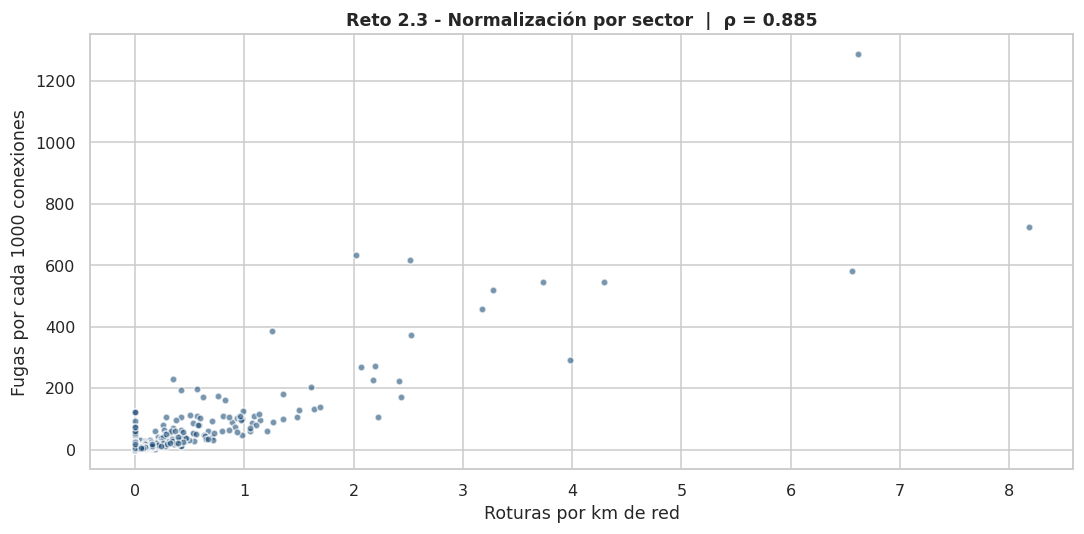

In [13]:
# Gráfico de dispersión roturas/km vs fugas/1000 conex
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(base_sector["roturas_por_km"], base_sector["fugas_por_1000conex"],
           s=20, alpha=0.6, edgecolor="white", color="#1F4E78")
ax.set_xlabel("Roturas por km de red")
ax.set_ylabel("Fugas por cada 1000 conexiones")
ax.set_title(f"Reto 2.3 - Normalización por sector  |  ρ = {corr:.3f}",
             fontweight="bold")
plt.tight_layout(); plt.show()

#4.2.4 Fase 3.4 - Análisis de Agrupamiento (K-means)

k óptimo según silhouette: 2 (score = 0.789)
   k=2: silhouette=0.789 | inertia=668.5  <- óptimo
   k=3: silhouette=0.474 | inertia=383.9
   k=4: silhouette=0.488 | inertia=282.9
   k=5: silhouette=0.412 | inertia=223.1
   k=6: silhouette=0.433 | inertia=177.6
   k=7: silhouette=0.445 | inertia=154.1


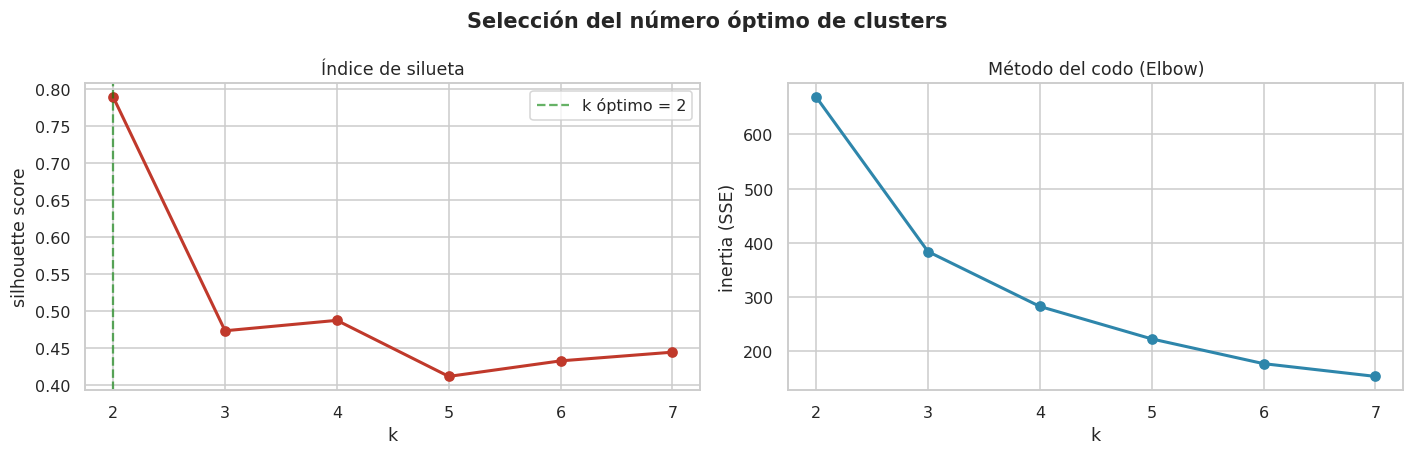

In [14]:
FEATURES_CLU = ["caudal_l_s", "roturas_por_km", "fugas_por_1000conex"]
df_clu = base_sector[["SECTOR"] + FEATURES_CLU].dropna().reset_index(drop=True)
X = StandardScaler().fit_transform(df_clu[FEATURES_CLU])

# Curvas para selección de k
ks = list(range(2, 8))
sils, inertias = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X)
    sils.append(silhouette_score(X, km.labels_))
    inertias.append(km.inertia_)

k_opt = ks[int(np.argmax(sils))]
print(f"k óptimo según silhouette: {k_opt} (score = {max(sils):.3f})")
for k, s, ix in zip(ks, sils, inertias):
    flag = "  <- óptimo" if k == k_opt else ""
    print(f"   k={k}: silhouette={s:.3f} | inertia={ix:.1f}{flag}")

# Visualización de la elección de k
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(ks, sils, "o-", color="#C0392B", lw=2)
ax[0].axvline(k_opt, ls="--", color="green", alpha=0.6, label=f"k óptimo = {k_opt}")
ax[0].set_xlabel("k"); ax[0].set_ylabel("silhouette score")
ax[0].set_title("Índice de silueta"); ax[0].legend()

ax[1].plot(ks, inertias, "o-", color="#2E86AB", lw=2)
ax[1].set_xlabel("k"); ax[1].set_ylabel("inertia (SSE)")
ax[1].set_title("Método del codo (Elbow)")
plt.suptitle("Selección del número óptimo de clusters", fontweight="bold")
plt.tight_layout(); plt.show()


In [15]:
# Ajuste final con k óptimo
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=50).fit(X)
df_clu["cluster_id"] = km_final.labels_

# Etiquetas operativas: Se ordena los clusters por criticidad descendente
# (mayor caudal + más roturas/km + más fugas/conexión => mas crítico)
centroids = pd.DataFrame(km_final.cluster_centers_, columns=FEATURES_CLU)
centroids["score"] = centroids.sum(axis=1)
orden_critic = centroids["score"].rank(ascending=False).astype(int)
mapa_label = {idx: f"C{int(rk)}" for idx, rk in orden_critic.items()}
df_clu["Cluster"] = df_clu["cluster_id"].map(mapa_label)

base_sector = base_sector.merge(df_clu[["SECTOR", "Cluster"]], on="SECTOR", how="left")

print("Distribución de sectores por cluster:")
print(base_sector["Cluster"].value_counts().to_string())

# Resumen por cluster
print("\nPerfil promedio por cluster (descendente en criticidad):")
perfil = (base_sector.groupby("Cluster")[FEATURES_CLU + ["total_roturas","total_fugas"]]
          .mean().round(2))
perfil["n_sectores"] = base_sector["Cluster"].value_counts()
print(perfil.to_string())

Distribución de sectores por cluster:
Cluster
C2    389
C1     11

Perfil promedio por cluster (descendente en criticidad):
         caudal_l_s  roturas_por_km  fugas_por_1000conex  total_roturas  total_fugas  n_sectores
Cluster                                                                                         
C1            48.12            4.26               597.22           17.0       204.73          11
C2            82.76            0.29                33.83            9.6       126.97         389


#4.3 RETO 3 - Calculo de Fugas Atendidas por cada Cuadrilla
#días 24/04/25, 25/04/25, 26/04/25, 27/04/25

In [16]:
#Establece fugas_día como el total de las fugas en cada día del total de los días
fugas_dia = fugas[fugas["fecha_inicio"].dt.date.isin(DIAS_OBJETIVO)].copy().reset_index(drop=True)
print(f"Total de fugas en los 4 días objetivo: {len(fugas_dia)}")
print(fugas_dia["fecha_inicio"].dt.date.value_counts().sort_index().to_string())


#Asigna a la fuga ña cuadrilla más cercana dependiendo de las coordenadas de estas
def asignar_cuadrilla_mas_cercana(lat, lon, cuadrillas):
    d = np.sqrt((cuadrillas["latitud"] - lat) ** 2 +
                (cuadrillas["longitud"] - lon) ** 2)
    idx = d.idxmin()
    return cuadrillas.loc[idx, "codigo"], float(d.loc[idx])

fugas_dia[["cuadrilla", "dist_a_cuadrilla"]] = fugas_dia.apply(
    lambda r: asignar_cuadrilla_mas_cercana(r["latitud"], r["longitud"], CUADRILLAS),
    axis=1, result_type="expand")

print("\nDistribución por día y cuadrilla:")
print(pd.crosstab(fugas_dia["fecha_inicio"].dt.date, fugas_dia["cuadrilla"]).to_string())


Total de fugas en los 4 días objetivo: 542
fecha_inicio
2025-04-24    158
2025-04-25    134
2025-04-26    131
2025-04-27    119

Distribución por día y cuadrilla:
cuadrilla     C1  C2  C3
fecha_inicio            
2025-04-24    52  55  51
2025-04-25    51  52  31
2025-04-26    45  35  51
2025-04-27    50  36  33


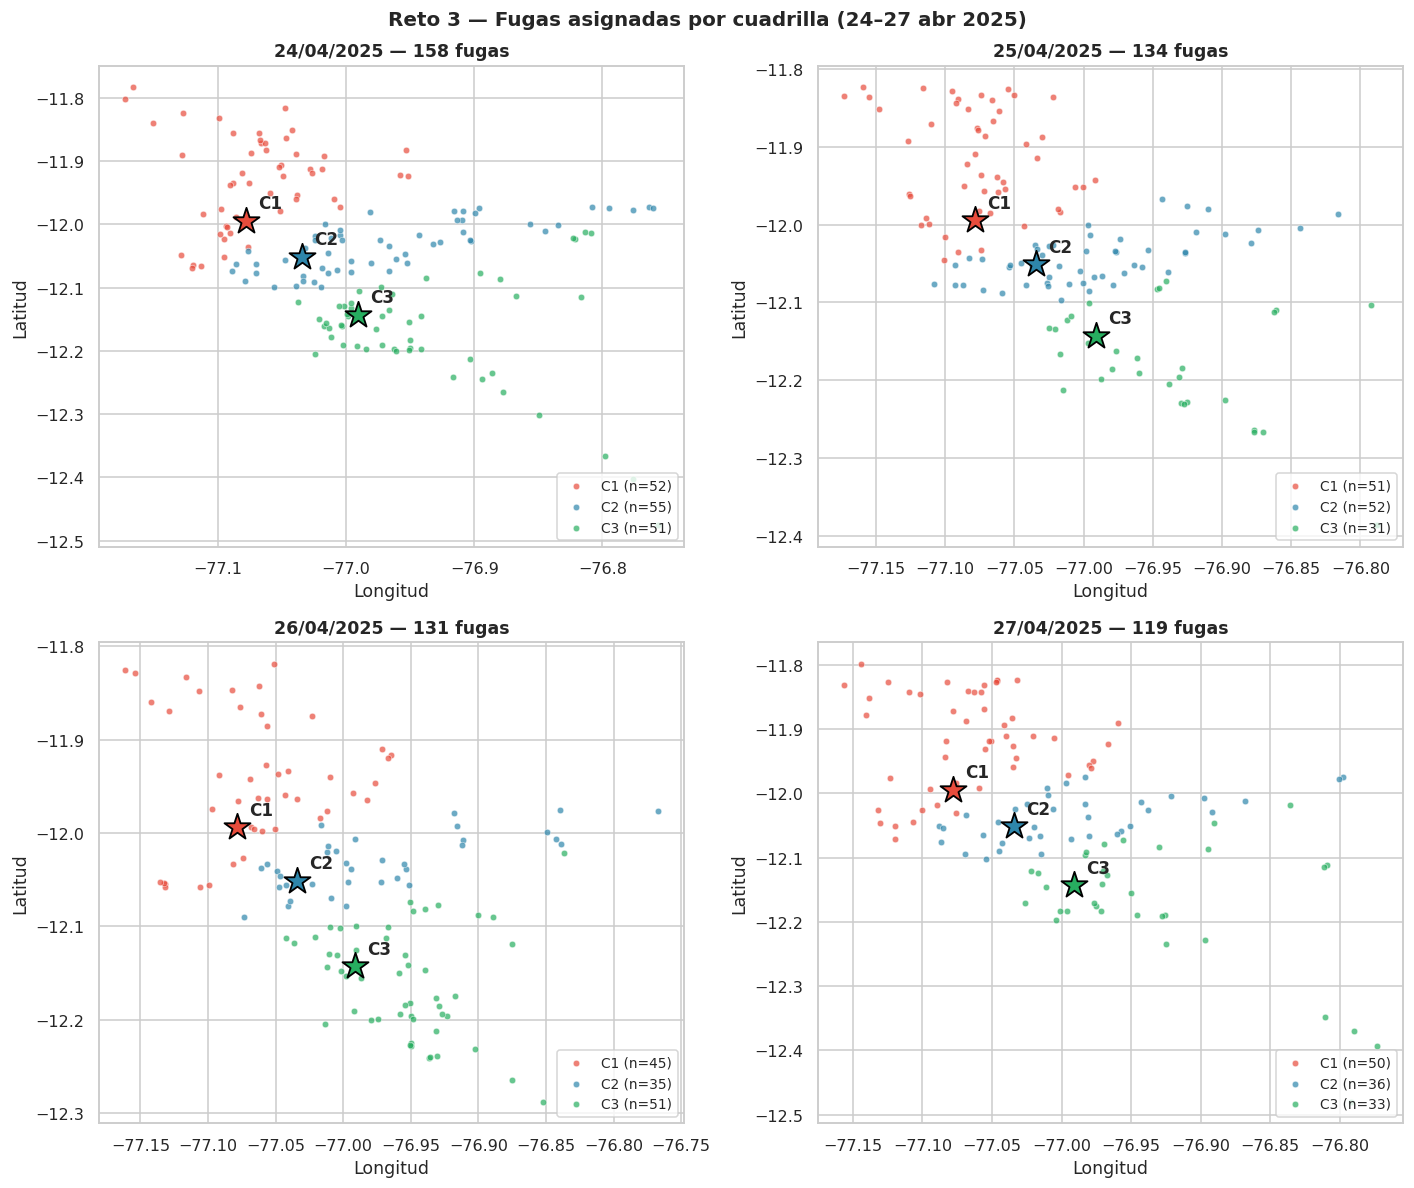

In [17]:
# Visualización: mapa de fugas por cuadrilla en los 4 días
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()
COL_CUADRILLA = {"C1": "#E74C3C", "C2": "#2E86AB", "C3": "#27AE60"}

for i, dia in enumerate(DIAS_OBJETIVO):
    ax = axes[i]
    sub = fugas_dia[fugas_dia["fecha_inicio"].dt.date == dia]
    for cu_code, color in COL_CUADRILLA.items():
        s = sub[sub["cuadrilla"] == cu_code]
        ax.scatter(s["longitud"], s["latitud"], color=color, s=18, alpha=0.7,
                   edgecolor="white", lw=0.4, label=f"{cu_code} (n={len(s)})")
    # Marca de las Cuadrillas
    for _, cu in CUADRILLAS.iterrows():
        ax.scatter(cu["longitud"], cu["latitud"], color=COL_CUADRILLA[cu["codigo"]],
                   marker="*", s=320, edgecolor="black", lw=1.2)
        ax.annotate(cu["codigo"], (cu["longitud"], cu["latitud"]),
                    xytext=(8, 8), textcoords="offset points",
                    fontsize=11, fontweight="bold")
    ax.set_title(f"{dia.strftime('%d/%m/%Y')} — {len(sub)} fugas", fontweight="bold")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Reto 3 — Fugas asignadas por cuadrilla (24–27 abr 2025)",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

# 4.4 Reto 4: Calculo de la Senda Óptima de Reparaciones por Cuadrilla

In [18]:
def dist_eu(p1, p2):
    return np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

def ruta_total(orden, puntos, origen):
    pts = [origen] + [puntos[i] for i in orden] + [origen]
    return sum(dist_eu(pts[i], pts[i + 1]) for i in range(len(pts) - 1))

def nearest_neighbor(puntos, origen):
    pendientes = list(range(len(puntos)))
    orden = []
    actual = origen
    while pendientes:
        i_best = min(pendientes, key=lambda i: dist_eu(actual, puntos[i]))
        orden.append(i_best)
        pendientes.remove(i_best)
        actual = puntos[i_best]
    return orden

def two_opt(orden, puntos, origen, max_iter=300):
    """Mejora la ruta por 2-opt swaps. Se detiene en óptimo local."""
    mejor = orden[:]
    mejor_dist = ruta_total(mejor, puntos, origen)
    n = len(mejor)
    mejorado = True
    it = 0
    while mejorado and it < max_iter:
        mejorado = False
        it += 1
        for i in range(n - 1):
            for j in range(i + 1, n):
                nuevo = mejor[:i] + mejor[i:j + 1][::-1] + mejor[j + 1:]
                nd = ruta_total(nuevo, puntos, origen)
                if nd < mejor_dist - 1e-9:
                    mejor, mejor_dist = nuevo, nd
                    mejorado = True
    return mejor, mejor_dist

print("Funciones TSP definidas: dist_eu, ruta_total, nearest_neighbor, two_opt.")

Funciones TSP definidas: dist_eu, ruta_total, nearest_neighbor, two_opt.


In [19]:
senda_optima = {}             # (cuadrilla, dia) - [CONEXION en orden]
distancias_senda = {}         # (cuadrilla, dia) - dist total
matriz_distancias_dia = {}    # dia -> DataFrame  (cuadrilla x R1..Rn)

for dia in DIAS_OBJETIVO:
    sub_dia = fugas_dia[fugas_dia["fecha_inicio"].dt.date == dia].copy().reset_index(drop=True)

    # Matriz cuadrilla x fugas para ese día
    md_dia = pd.DataFrame(index=CUADRILLAS["codigo"].values,
                          columns=[f"R{i+1}" for i in range(len(sub_dia))],
                          dtype=float)
    for i, fuga in sub_dia.iterrows():
        for _, cu in CUADRILLAS.iterrows():
            md_dia.loc[cu["codigo"], f"R{i+1}"] = np.sqrt(
                (cu["latitud"] - fuga["latitud"]) ** 2 +
                (cu["longitud"] - fuga["longitud"]) ** 2)
    md_dia.index.name = "cuadrilla"
    matriz_distancias_dia[dia] = md_dia

    # TSP por cada cuadrilla
    for cu_code in CUADRILLAS["codigo"].values:
        cu_row = CUADRILLAS[CUADRILLAS["codigo"] == cu_code].iloc[0]
        origen = (cu_row["latitud"], cu_row["longitud"])
        cu_fugas = sub_dia[sub_dia["cuadrilla"] == cu_code].reset_index(drop=True)
        if len(cu_fugas) == 0:
            senda_optima[(cu_code, dia)] = []
            distancias_senda[(cu_code, dia)] = 0.0
            continue
        puntos = list(zip(cu_fugas["latitud"].tolist(), cu_fugas["longitud"].tolist()))
        orden_ini = nearest_neighbor(puntos, origen)
        orden_fin, dist_fin = two_opt(orden_ini, puntos, origen)
        senda_optima[(cu_code, dia)] = cu_fugas.iloc[orden_fin]["CONEXION"].tolist()
        distancias_senda[(cu_code, dia)] = dist_fin

# Resumen
print("Distancias totales por ruta (en grados, escala euclidiana sobre lat/lon):")
print(f"{'Cuadrilla':<10} | " + " | ".join(d.strftime('%d/%m') for d in DIAS_OBJETIVO))
print("-" * 56)
for cu in ["C1", "C2", "C3"]:
    fila = " | ".join(f"{distancias_senda[(cu, d)]:.4f}" for d in DIAS_OBJETIVO)
    print(f"{cu:<10} | {fila}")

Distancias totales por ruta (en grados, escala euclidiana sobre lat/lon):
Cuadrilla  | 24/04 | 25/04 | 26/04 | 27/04
--------------------------------------------------------
C1         | 1.2451 | 1.0339 | 1.0795 | 1.2393
C2         | 1.1014 | 0.9677 | 0.8976 | 0.9539
C3         | 1.6060 | 1.1009 | 1.1442 | 1.3932


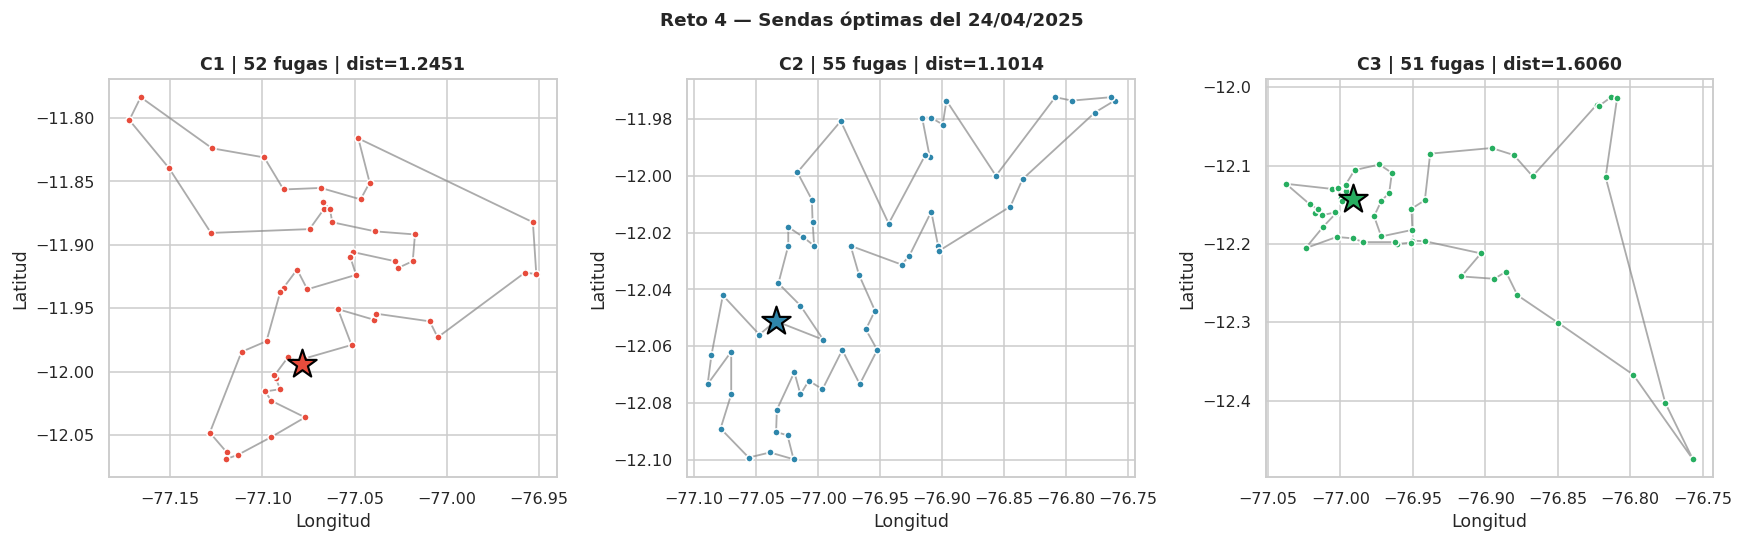

In [20]:
# Visualización: rutas TSP del primer día (los demás tienen el mismo formato)
dia_demo = DIAS_OBJETIVO[0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cu_code in zip(axes, ["C1", "C2", "C3"]):
    cu = CUADRILLAS[CUADRILLAS["codigo"] == cu_code].iloc[0]
    ids = senda_optima[(cu_code, dia_demo)]
    sub = fugas_dia[(fugas_dia["fecha_inicio"].dt.date == dia_demo) &
                    (fugas_dia["cuadrilla"] == cu_code)].set_index("CONEXION")
    if len(ids):
        # Conservar orden de la senda
        orden = sub.loc[ids]
        xs = [cu["longitud"]] + orden["longitud"].tolist() + [cu["longitud"]]
        ys = [cu["latitud"]]  + orden["latitud"].tolist()  + [cu["latitud"]]
        ax.plot(xs, ys, "-", color="#888", lw=1.2, alpha=0.7)
        ax.scatter(orden["longitud"], orden["latitud"],
                   c=COL_CUADRILLA[cu_code], s=22, edgecolor="white", zorder=3)
    ax.scatter(cu["longitud"], cu["latitud"], marker="*", s=380,
               color=COL_CUADRILLA[cu_code], edgecolor="black", lw=1.4, zorder=4)
    ax.set_title(f"{cu_code} | {len(ids)} fugas | "
                 f"dist={distancias_senda[(cu_code, dia_demo)]:.4f}",
                 fontweight="bold")
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
plt.suptitle(f"Reto 4 — Sendas óptimas del {dia_demo.strftime('%d/%m/%Y')}",
             fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()